In [3]:
import os
import warnings
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error


import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from math import sqrt

In [4]:
try:
  import pmdarima as pm
except Exception:
  pm = None

In [5]:
try:
    from etna.datasets import TSDataset
    from etna.models.nn import RNNModel
    from etna.models import DeepARModel
    ETNA_AVAILABLE = True
except Exception:
    ETNA_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [6]:
plt.style.use('seaborn-v0_8')
sns.set_context('talk')

In [7]:
DATA_DIRS = [Path('/mnt/data'), Path('.')]
skab_filename = 'skab_valve_1.csv'
nab_filename = 'machine_temperature_system_failure.csv'

In [8]:
df_skab = None
df_nab = None
loaded_paths = []

for d in DATA_DIRS:
    skab_path = d / skab_filename
    nab_path = d / nab_filename
    if skab_path.exists():
        loaded_paths.append(str(skab_path))
        # try to infer separator: if file parsed into 1 column and that contains ';', re-parse with sep=';'
        tmp = pd.read_csv(skab_path, nrows=5, dtype=str)
        if tmp.shape[1] == 1 and tmp.iloc[:, 0].str.contains(';').any():
            df_skab = pd.read_csv(skab_path, sep=';', engine='python')
        else:
            # try comma or semicolon automatically
            try:
                df_skab = pd.read_csv(skab_path)
            except Exception:
                df_skab = pd.read_csv(skab_path, sep=';')
    if nab_path.exists():
        loaded_paths.append(str(nab_path))
        try:
            df_nab = pd.read_csv(nab_path)
        except Exception:
            df_nab = pd.read_csv(nab_path, sep=';')

print("Loaded files:", loaded_paths)
if df_skab is not None:
    print("\nSKAB columns sample:", df_skab.columns.tolist()[:20])
if df_nab is not None:
    print("\nNAB columns sample:", df_nab.columns.tolist()[:20])

Loaded files: ['machine_temperature_system_failure.csv']

NAB columns sample: ['timestamp', 'value']


In [9]:
def extract_time_series_from_skab(df):
    # try to detect time column and thermocouple column
    cols = df.columns
    time_candidates = [c for c in cols if 'time' in c.lower() or 'date' in c.lower() or 'datetime' in c.lower()]
    value_candidates = [c for c in cols if 'therm' in c.lower() or 'temp' in c.lower()]
    # fallback: if header is one string with semicolons, handled earlier
    if len(value_candidates) == 0:
        # try exact 'Thermocouple' name
        for c in cols:
            if c.lower() == 'thermocouple':
                value_candidates.append(c)
    if len(value_candidates) == 0:
        return None, None, None
    value_col = value_candidates[0]
    time_col = time_candidates[0] if time_candidates else None
    df2 = df.copy()
    if time_col is not None:
        try:
            df2[time_col] = pd.to_datetime(df2[time_col])
            df2 = df2.set_index(time_col)
        except Exception:
            # maybe time has format without explicit parseable strings - skip index
            pass
    # coerce to numeric
    ser = pd.to_numeric(df2[value_col], errors='coerce').dropna()
    if ser.empty:
        return None, None, None
    return ser, value_col, df2.index.name

In [10]:
def extract_time_series_from_nab(df):
    # NAB expected columns: timestamp, value
    cols = df.columns
    time_col = None
    val_col = None
    for c in cols:
        if 'timestamp' in c.lower() or 'time' in c.lower() or 'date' in c.lower():
            time_col = c
            break
    for c in cols:
        if 'value' in c.lower() or 'temp' in c.lower():
            val_col = c
            break
    if val_col is None:
        # fallback to second column
        if len(cols) >= 2:
            val_col = cols[1]
        else:
            val_col = cols[0]
    df2 = df.copy()
    if time_col is not None:
        try:
            df2[time_col] = pd.to_datetime(df2[time_col])
            df2 = df2.set_index(time_col)
        except Exception:
            pass
    ser = pd.to_numeric(df2[val_col], errors='coerce').dropna()
    return ser, val_col, time_col

In [11]:
ts = None
source = None
chosen_col = None
time_index_name = None

if df_skab is not None:
    ser, valc, time_index_name = extract_time_series_from_skab(df_skab)
    if ser is not None and len(ser) > 10:
        ts = ser.sort_index()
        source = 'SKAB'
        chosen_col = valc

# If SKAB not selected or invalid, try NAB
if ts is None and df_nab is not None:
    ser, valc, time_index_name = extract_time_series_from_nab(df_nab)
    if ser is not None and len(ser) > 10:
        ts = ser.sort_index()
        source = 'NAB'
        chosen_col = valc

if ts is None:
    raise RuntimeError("Не удалось извлечь временной ряд из предоставленных CSV. Проверьте структуру файлов.")

print(f"Selected series from {source}, column '{chosen_col}', length={len(ts)}")
print("Index type:", type(ts.index))

Selected series from NAB, column 'value', length=22695
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


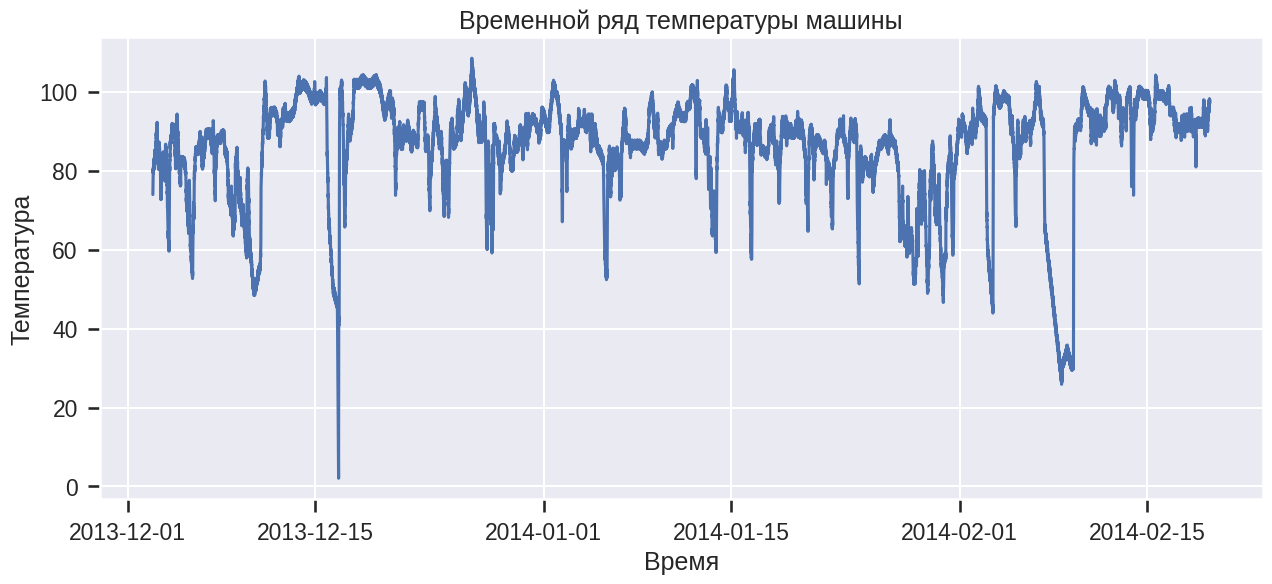

In [15]:
#Визуализация исходного ряда
plt.figure(figsize=(15, 6))
plt.plot(ts)
plt.title('Временной ряд температуры машины')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.grid(True)
plt.show()

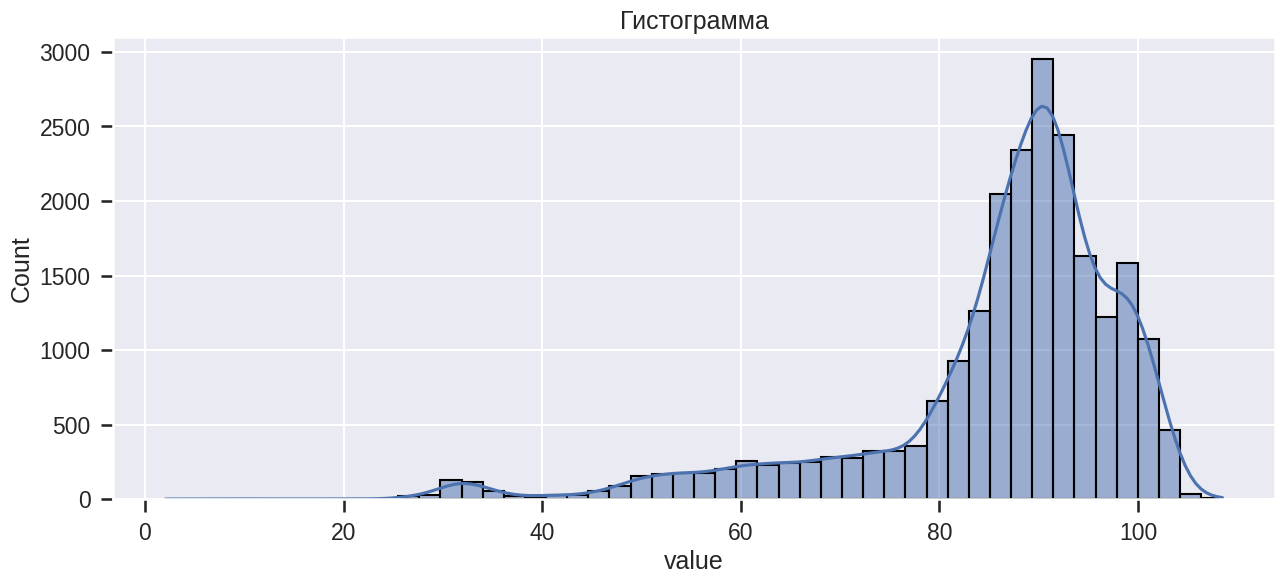

In [16]:
plt.figure(figsize=(15,6))
sns.histplot(ts, kde=True, bins=50)
plt.title("Гистограмма")
plt.show()

In [17]:
display(ts.describe())

,value
count,22695.000000
mean,85.926498
std,13.746912
min,2.084721
25%,83.080078
50%,89.408246
75%,94.016252
max,108.510543


In [18]:
test_size = 0.2
n = len(ts)
train_n = int((1 - test_size) * n)
train_ts = ts.iloc[:train_n]
test_ts = ts.iloc[train_n:]

print(f"Train length = {len(train_ts)}, Test length = {len(test_ts)} (split index = {train_n})")

Train length = 18156, Test length = 4539 (split index = 18156)


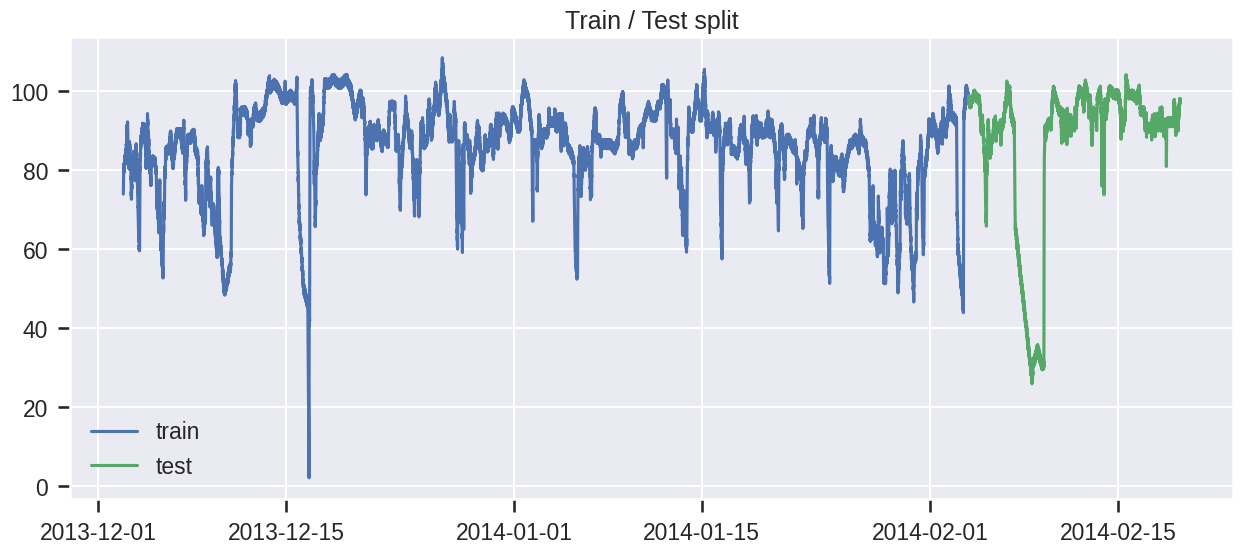

In [19]:
plt.figure(figsize=(15,6))
plt.plot(train_ts, label='train')
plt.plot(test_ts, label='test')
plt.legend()
plt.title("Train / Test split")
plt.show()

In [20]:
def rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))

In [21]:
naive_pred = pd.Series(train_ts.iloc[-1], index=test_ts.index)
mae_naive = mean_absolute_error(test_ts, naive_pred)
rmse_naive = rmse(test_ts, naive_pred)
print(f"Naive -> MAE: {mae_naive:.4f}, RMSE: {rmse_naive:.4f}")

Naive -> MAE: 12.0013, RMSE: 22.4795


In [22]:
window = 10 if len(train_ts) >= 20 else max(1, int(len(train_ts) / 5))
rolling_mean_val = train_ts.rolling(window=window).mean().iloc[-1]
rolling_pred = pd.Series(rolling_mean_val, index=test_ts.index)
mae_roll = mean_absolute_error(test_ts, rolling_pred)
rmse_roll = rmse(test_ts, rolling_pred)
print(f"Rolling mean (window={window}) -> MAE: {mae_roll:.4f}, RMSE: {rmse_roll:.4f}")

Rolling mean (window=10) -> MAE: 12.0234, RMSE: 22.5002


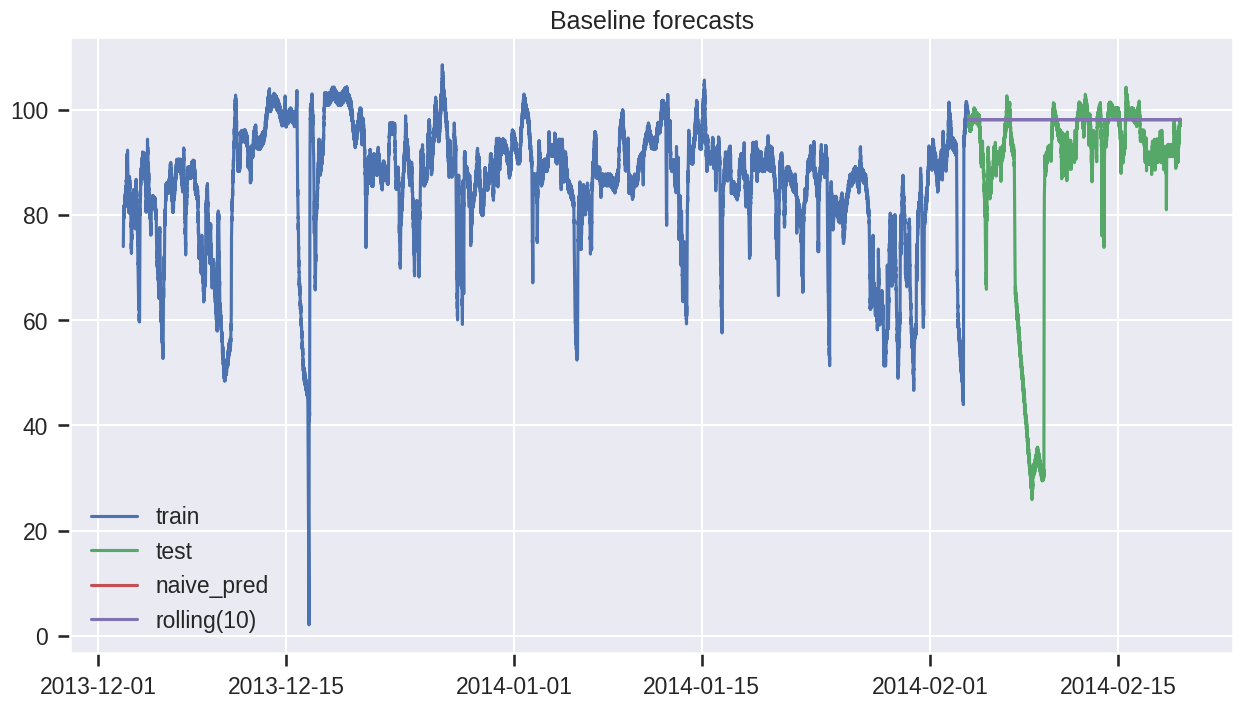

In [23]:
plt.figure(figsize=(15,8))
plt.plot(train_ts.index, train_ts, label='train')
plt.plot(test_ts.index, test_ts, label='test')
plt.plot(test_ts.index, naive_pred, label='naive_pred')
plt.plot(test_ts.index, rolling_pred, label=f'rolling({window})')
plt.legend()
plt.title('Baseline forecasts')
plt.show()

In [25]:
print("ADF on train:")
adf_res = adfuller(train_ts.dropna())
print(f"ADF statistic = {adf_res[0]:.4f}, p-value = {adf_res[1]:.4f}")
for k, v in adf_res[4].items():
    print(f"  critical value ({k}) = {v:.4f}")
if adf_res[1] < 0.05:
    print("=> Ряд можно считать стационарным на уровне значимости 5% (reject unit root).")
else:
    print("=> Ряд, вероятно, нестационарен (fail to reject unit root).")

ADF on train:
ADF statistic = -7.8376, p-value = 0.0000
  critical value (1%) = -3.4307
  critical value (5%) = -2.8617
  critical value (10%) = -2.5669
=> Ряд можно считать стационарным на уровне значимости 5% (reject unit root).


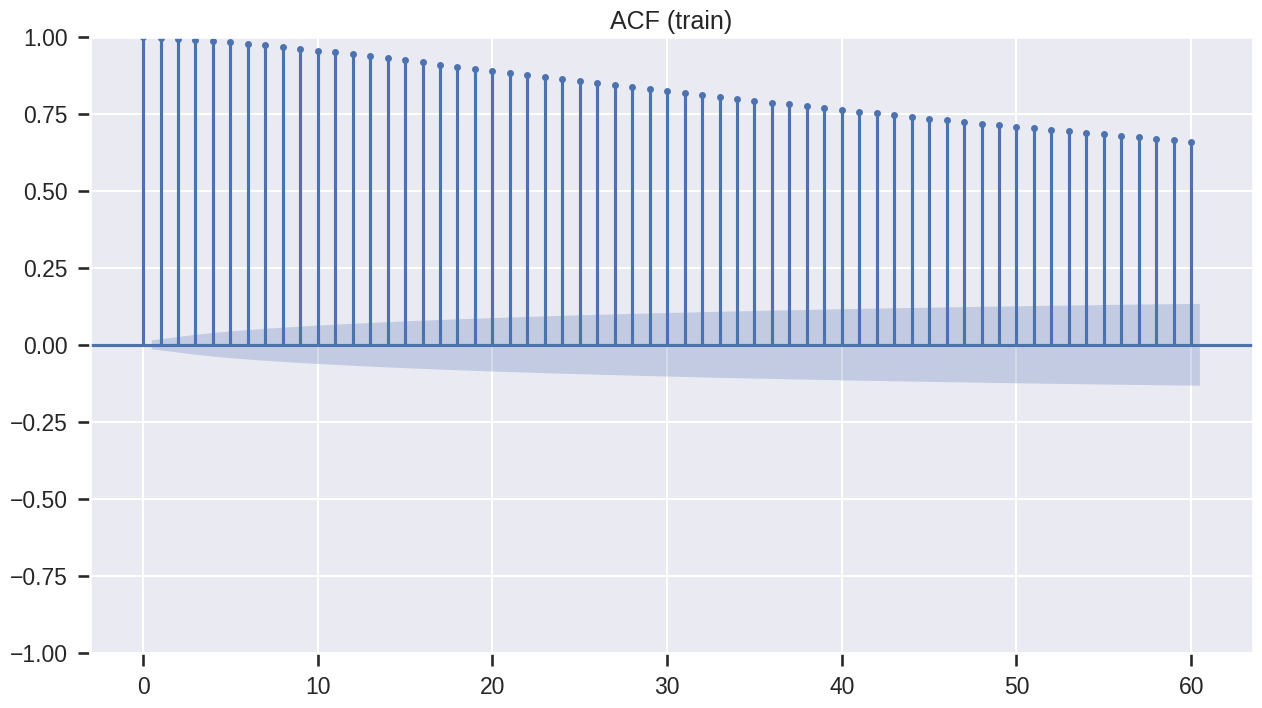

In [26]:
plt.figure(figsize=(15,8))
plot_acf(train_ts.dropna(), lags=60, ax=plt.gca())
plt.title("ACF (train)")
plt.show()

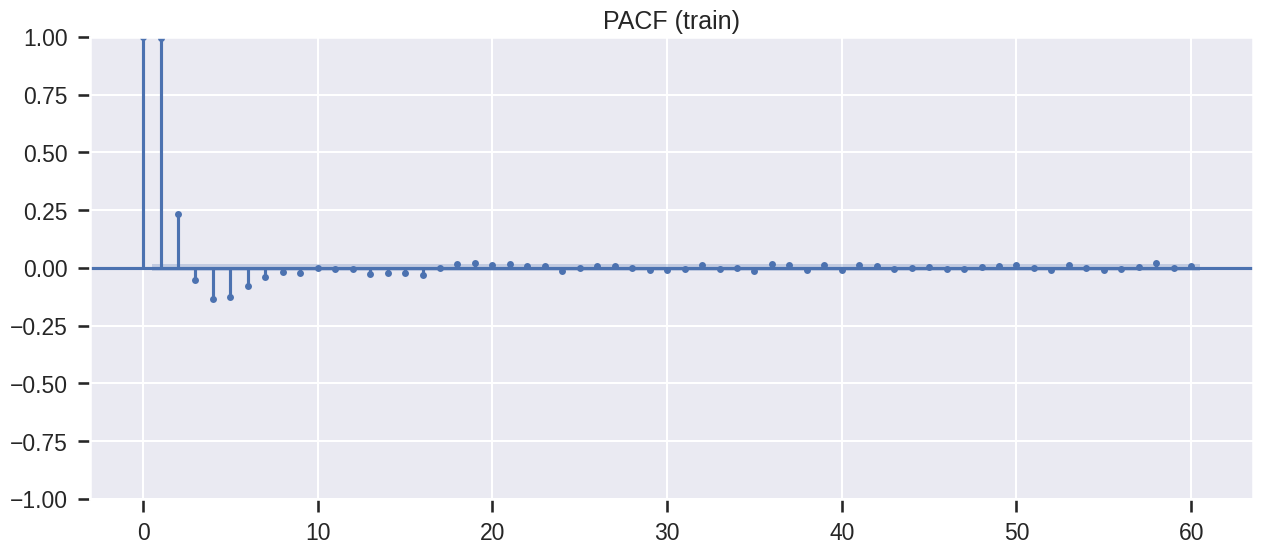

In [45]:
plt.figure(figsize=(15,6))
plot_pacf(train_ts.dropna(), lags=60, ax=plt.gca(), method='ywm')
plt.title("PACF (train)")
plt.show()

In [48]:
use_log = (train_ts > 0).all()
if use_log:
    train_log = np.log(train_ts)
    print("Применено log-transform")
else:
    train_log = None
    print("Log-transform пропущен (есть неположительные значения)")

if train_log is not None:
    diff1 = train_log.diff().dropna()
else:
    diff1 = train_ts.diff().dropna()

Применено log-transform


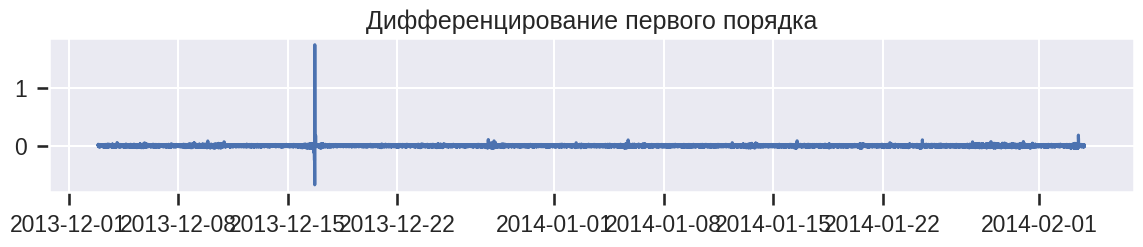

In [49]:
plt.figure(figsize=(14,2))
plt.plot(diff1)
plt.title("Дифференцирование первого порядка")
plt.show()

In [50]:
adf_diff = adfuller(diff1.dropna())
print(f"ADF on diff: statistic = {adf_diff[0]:.4f}, p-value = {adf_diff[1]:.4f}")
if adf_diff[1] < 0.05:
    print("=> Разностный ряд стационарен (на 5% уровне).")
else:
    print("=> Разностный ряд может быть нестационарен — рассмотрите сезонное дифференцирование.")

ADF on diff: statistic = -28.9240, p-value = 0.0000
=> Разностный ряд стационарен (на 5% уровне).


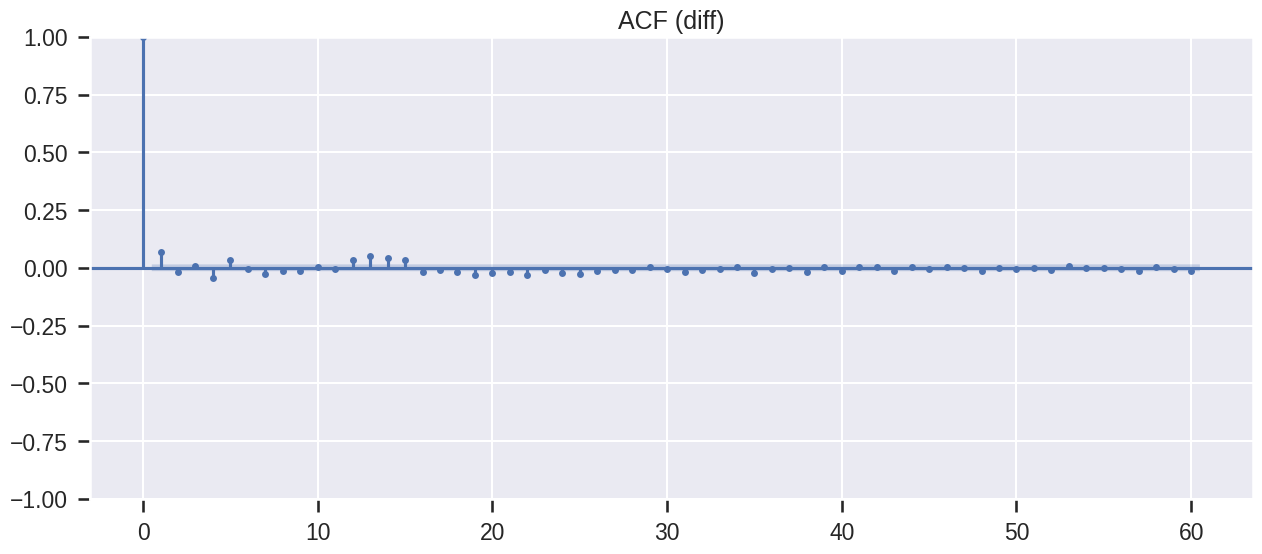

In [51]:
plt.figure(figsize=(15,6))
plot_acf(diff1.dropna(), lags=60, ax=plt.gca())
plt.title("ACF (diff)")
plt.show()

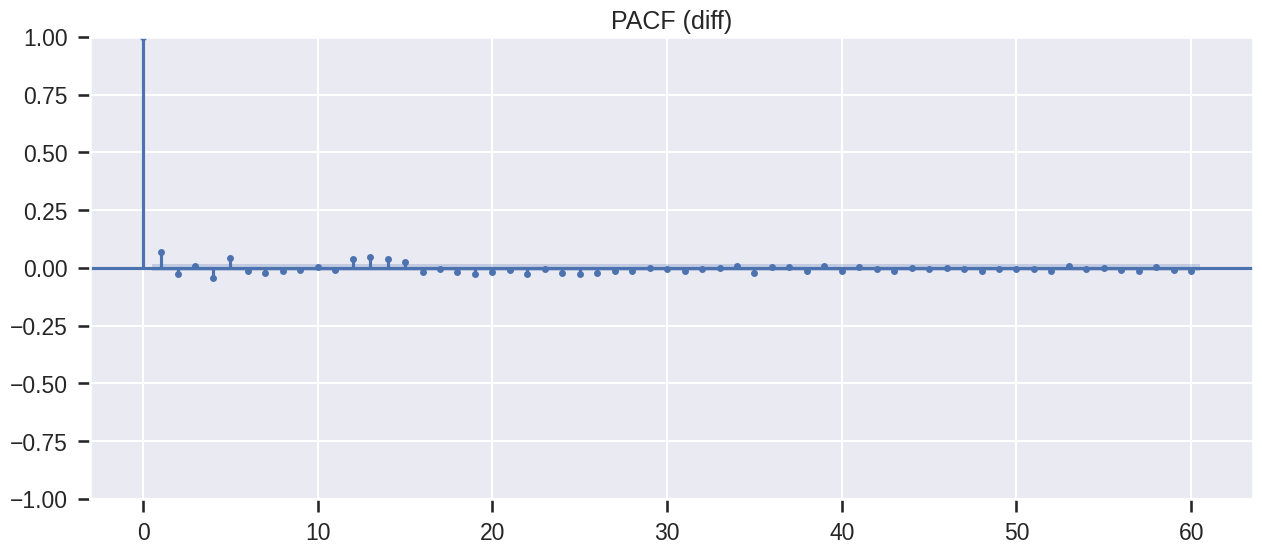

In [53]:
plt.figure(figsize=(15,6))
plot_pacf(diff1.dropna(), lags=60, ax=plt.gca(), method='ywm')
plt.title("PACF (diff)")
plt.show()

In [54]:
d = 1 if adf_res[1] > 0.05 else 0
print("Selected d =", d, "based on ADF p-value =", adf_res[1])

Selected d = 0 based on ADF p-value = 6.055169390972298e-12


In [55]:
p_max = 3
q_max = 3
best_aic = np.inf
best_order = None
best_res = None

for p in range(0, p_max + 1):
    for q in range(0, q_max + 1):
        try:
            mod = sm.tsa.SARIMAX(train_ts, order=(p, d, q),
                                 enforce_stationarity=False,
                                 enforce_invertibility=False)
            res = mod.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = (p, d, q)
                best_res = res
        except Exception:
            continue

print("Best SARIMAX order:", best_order, "AIC:", best_aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Best SARIMAX order: (3, 0, 3) AIC: 52580.49352584974


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


SARIMAX(3, 0, 3) -> MAE: 22.1237, RMSE: 26.1415


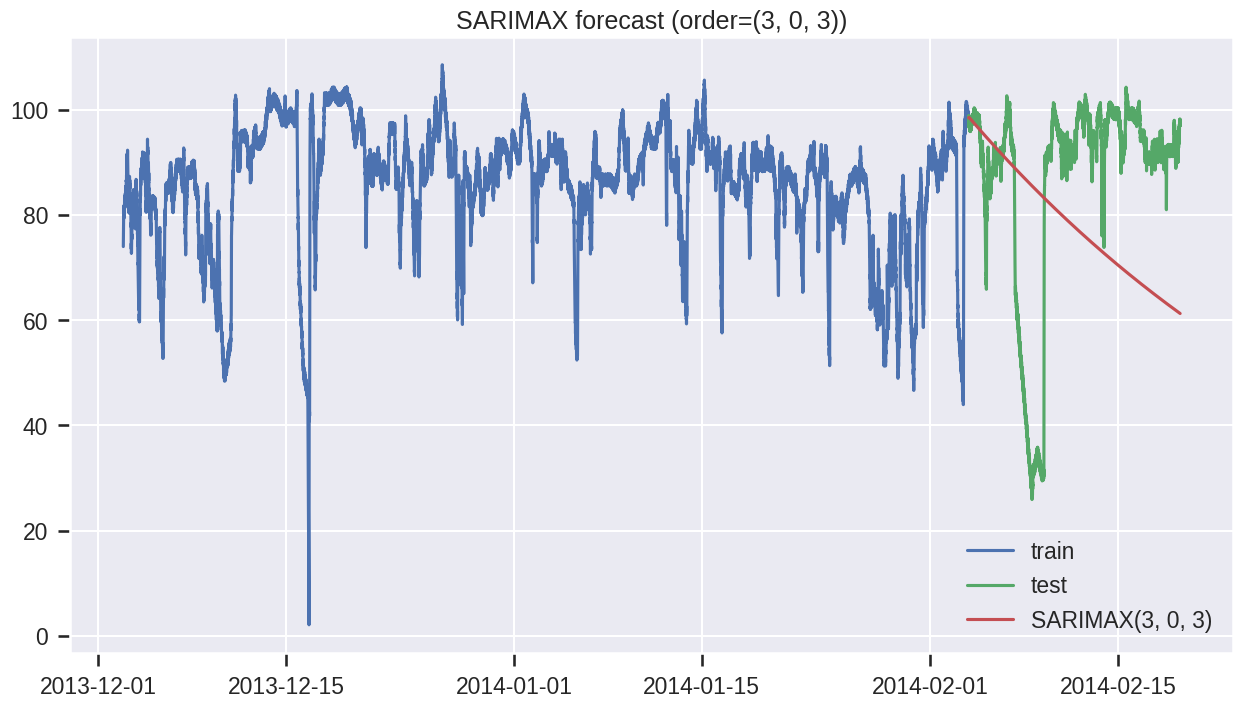

In [58]:
if best_res is not None:
    steps = len(test_ts)
    forecast_sarimax = best_res.get_forecast(steps=steps).predicted_mean
    forecast_sarimax.index = test_ts.index
    mae_sarimax = mean_absolute_error(test_ts, forecast_sarimax)
    rmse_sarimax = rmse(test_ts, forecast_sarimax)
    print(f"SARIMAX{best_order} -> MAE: {mae_sarimax:.4f}, RMSE: {rmse_sarimax:.4f}")

    plt.figure(figsize=(15,8))
    plt.plot(train_ts.index, train_ts, label='train')
    plt.plot(test_ts.index, test_ts, label='test')
    plt.plot(test_ts.index, forecast_sarimax, label=f'SARIMAX{best_order}')
    plt.legend()
    plt.title(f'SARIMAX forecast (order={best_order})')
    plt.show()
else:
    print("Не удалось подобрать SARIMAX модель в заданном диапазоне p,q.")

In [59]:
df_fe = pd.DataFrame(ts)
df_fe.columns = ['y']

In [60]:
max_lag = 24 if len(df_fe) > 100 else max(5, int(len(df_fe) / 10))
for lag in range(1, max_lag + 1):
    df_fe[f'lag_{lag}'] = df_fe['y'].shift(lag)

In [61]:
windows = [3, 6, 12] if len(df_fe) > 30 else [3, max(1, int(len(df_fe)/6))]
for w in windows:
    df_fe[f'roll_mean_{w}'] = df_fe['y'].shift(1).rolling(window=w).mean()
    df_fe[f'roll_std_{w}'] = df_fe['y'].shift(1).rolling(window=w).std()

In [62]:
if isinstance(df_fe.index, pd.DatetimeIndex):
    df_fe['hour'] = df_fe.index.hour
    df_fe['dayofweek'] = df_fe.index.dayofweek
    df_fe['month'] = df_fe.index.month

In [63]:
df_fe['y_target'] = df_fe['y'].shift(-1)
df_fe = df_fe.dropna()

In [64]:
train_fe = df_fe.iloc[:train_n - 1]
test_fe = df_fe.iloc[train_n - 1: n - 1]

X_train = train_fe.drop(columns=['y', 'y_target'])
y_train = train_fe['y_target']
X_test = test_fe.drop(columns=['y', 'y_target'])
y_test = test_fe['y_target']

print("Shapes: X_train", X_train.shape, "X_test", X_test.shape)

Shapes: X_train (18155, 33) X_test (4515, 33)


In [65]:
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = rmse(y_test, rf_pred)
print(f"RandomForest -> MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}")

RandomForest -> MAE: 0.8959, RMSE: 1.2620


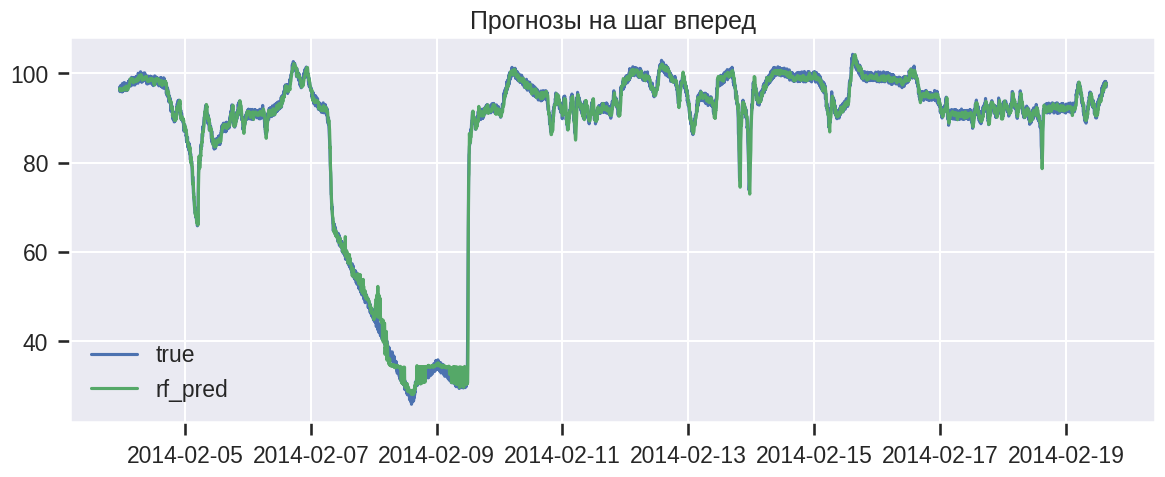

In [67]:
plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label='true')
plt.plot(y_test.index, rf_pred, label='rf_pred')
plt.legend()
plt.title("Прогнозы на шаг вперед")
plt.show()

In [68]:
etna_results = {}
if ETNA_AVAILABLE:
    print("ETNA is available — готовлю TSDataset и обучаю модели (может занять время).")
    # Prepare dataframe for ETNA
    df_etna = pd.DataFrame({'timestamp': ts.index, 'segment': 'series_1', 'target': ts.values})
    ts_dataset = TSDataset(df_etna, freq=pd.infer_freq(ts.index) or 'D')

    # RNNModel (attempt)
    try:
        rnn = RNNModel(input_size=10, hidden_size=32, num_layers=1, optimizer_kwargs={'lr': 1e-3}, random_state=RANDOM_STATE)
        rnn.fit(ts_dataset)
        future = rnn.forecast(ts_dataset, horizon=len(test_ts))
        pred_rnn = future.pivot(index='timestamp', columns='segment', values='target')['series_1'].values
        mae_rnn = mean_absolute_error(test_ts.values, pred_rnn)
        rmse_rnn = rmse(test_ts.values, pred_rnn)
        etna_results['RNN'] = (mae_rnn, rmse_rnn)
        print("RNN done:", etna_results['RNN'])
    except Exception as e:
        print("RNN failed:", e)

    # DeepARModel (attempt)
    try:
        deepar = DeepARModel(quantiles=[0.5], hidden_size=32, n_epochs=5, random_state=RANDOM_STATE)
        deepar.fit(ts_dataset)
        future_deepar = deepar.forecast(ts_dataset, horizon=len(test_ts))
        pred_deepar = future_deepar.pivot(index='timestamp', columns='segment', values='target')['series_1'].values
        mae_deepar = mean_absolute_error(test_ts.values, pred_deepar)
        rmse_deepar = rmse(test_ts.values, pred_deepar)
        etna_results['DeepAR'] = (mae_deepar, rmse_deepar)
        print("DeepAR done:", etna_results['DeepAR'])
    except Exception as e:
        print("DeepAR failed:", e)
else:
    print("ETNA not installed. Чтобы запустить ETNA, установите пакет `etna[all]`.")

ETNA not installed. Чтобы запустить ETNA, установите пакет `etna[all]`.


In [69]:
results = []
results.append({'model': 'naive', 'MAE': mae_naive, 'RMSE': rmse_naive})
results.append({'model': f'rolling_mean_{window}', 'MAE': mae_roll, 'RMSE': rmse_roll})

In [70]:
if 'mae_sarimax' in locals():
    results.append({'model': f'SARIMAX_{best_order}', 'MAE': mae_sarimax, 'RMSE': rmse_sarimax})
if 'mae_sarimax' not in locals() and best_res is not None:
    results.append({'model': f'SARIMAX_{best_order}', 'MAE': mae_sarimax if 'mae_sarimax' in locals() else mae_sarimax if 'mae_sarimax' in globals() else mean_absolute_error(test_ts, forecast_sarimax), 'RMSE': rmse(test_ts, forecast_sarimax)})
results.append({'model': 'RandomForest', 'MAE': mae_rf, 'RMSE': rmse_rf})

for k, v in etna_results.items():
    results.append({'model': k, 'MAE': v[0], 'RMSE': v[1]})

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
print("Results comparison:")
display(results_df)

Results comparison:


,model,MAE,RMSE
0,RandomForest,0.895908,1.261965
1,naive,12.001290,22.479489
2,rolling_mean_10,12.023365,22.500216
3,"SARIMAX_(3, 0, 3)",22.123708,26.141535
